# IMPORTS

## System

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# Remonte de deux niveaux (si ton notebook est dans /notebooks/exploration.ipynb)
# pour atteindre la racine du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from config.config import *

from PIL import Image

## Données

In [3]:
images_cancer_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / "cancer"
images_normal_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / "normal"

In [4]:
metadata_list = []
image:Path

for image in images_cancer_dir.glob('*') :
    img = Image.open(image)

    metadata = {
        'name' : image.name,
        'format' : img.format,
        'width' : img.width,
        'height' : img.height,
        'mode' : img.mode,
        'file_size' : os.path.getsize(image),
    }

    metadata_list.append(metadata)

df = pd.DataFrame(metadata_list)

In [5]:
df.head()

,name,format,width,height,mode,file_size
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,JPEG,512,512,RGB,25845
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,JPEG,512,512,RGB,18082
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,JPEG,512,512,RGB,18113
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,JPEG,512,512,RGB,24615
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,JPEG,512,512,RGB,24723


In [6]:
df.describe(include='all')

,name,format,width,height,mode,file_size
count,50,50,50.0,50.0,50,50.000000
unique,50,1,NaN,NaN,1,NaN
top,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,JPEG,NaN,NaN,RGB,NaN
freq,1,50,NaN,NaN,50,NaN
mean,NaN,NaN,512.0,512.0,NaN,23036.520000
std,NaN,NaN,0.0,0.0,NaN,4074.946246
min,NaN,NaN,512.0,512.0,NaN,16207.000000
25%,NaN,NaN,512.0,512.0,NaN,19788.000000
50%,NaN,NaN,512.0,512.0,NaN,23534.500000
75%,NaN,NaN,512.0,512.0,NaN,25819.000000


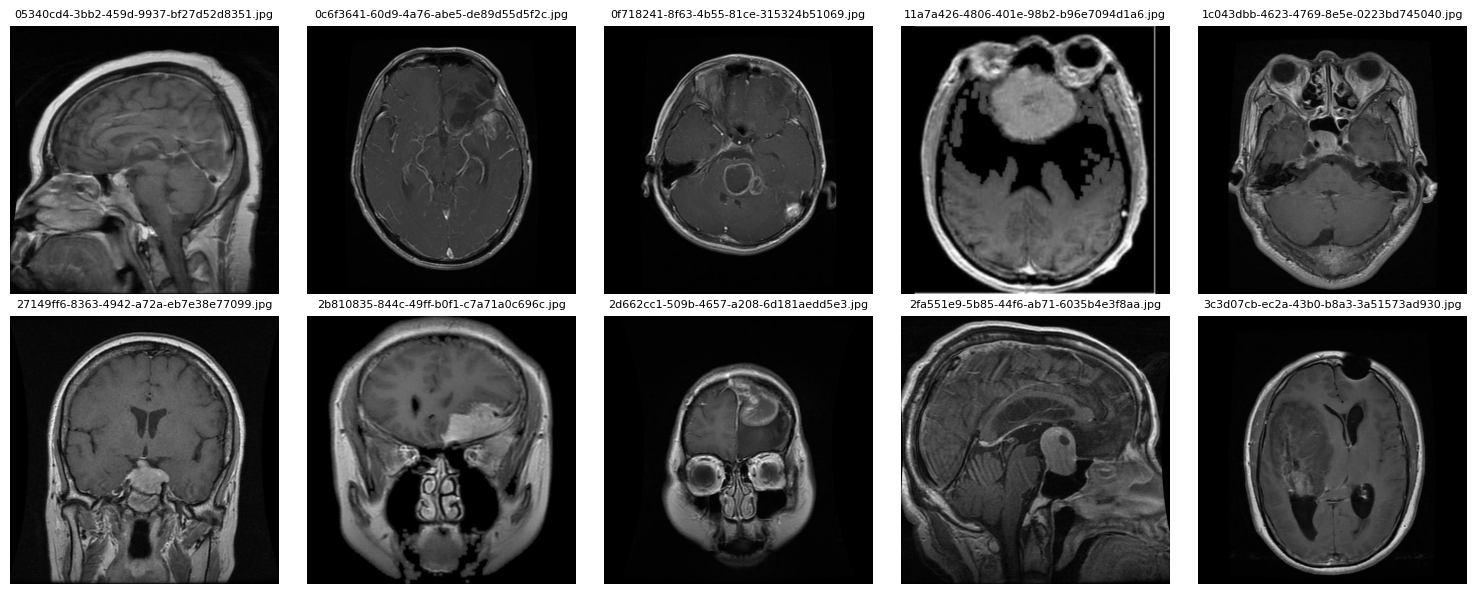

In [7]:
import matplotlib.pyplot as plt

# Récupérer les 10 premières images
images = list(images_cancer_dir.glob('*'))[:10]

# Créer une grille 2x5
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, img_path in enumerate(images):
    img = Image.open(img_path)
    axes[idx].imshow(img)  # Sans cmap='gray' pour afficher en couleur
    axes[idx].set_title(img_path.name, fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Observations :
- Nous avons 50 images labelisées au format JPEG
- Images carrées de 512px
- Toutes au format jpeg
- Taille : mean = 23 Ko ; min = 16 Ko ; max = 32.5 Ko
- Toutes en RGB
- Les images sont prises sous différentes orientations : Haut, coté, face